In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Part 1. Data Quality Report and Part 2. Data Quality Plan

This section audits the raw training dataset, identifies key data quality issues, and applies a justified cleaning pipeline to prepare the dataset for later analysis and modelling.

The main objectives are to:
1. inspect the structure and content of the raw training data;
2. identify duplicate rows, duplicate columns, constant columns, missing values, formatting problems, and outliers;
3. convert retained features into appropriate data types;
4. apply justified cleaning decisions and generate a clean final training dataset for later stages of the project.

A particularly important issue in the raw dataset is the high missingness of the `Eircode` field. Because this limits its direct use as a reliable spatial feature, it is not retained in the clean-final dataset. Spatial information is instead incorporated later in the notebook through externally geocoded latitude/longitude data and derived location-based features.

Although the test set is loaded for consistency of preprocessing in later sections, all data-quality decisions in Part 1 and Part 2 are based on the raw training dataset.

In [2]:

import numpy as np
import pandas as pd

# -----------------------------
# Load raw datasets for Part 1 and Part 2
# -----------------------------
train_df = pd.read_csv("ppr-group-24209891-train.csv")
test_df = pd.read_csv("ppr-group-24209891-test.csv")

# standardise column names
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print("The shape of train dataset is:", train_df.shape)
print("The shape of test dataset is:", test_df.shape)

print("\nTrain dtypes:")
print(train_df.dtypes)

The shape of train dataset is: (54000, 9)
The shape of test dataset is: (10000, 9)

Train dtypes:
Date of Sale (dd/mm/yyyy)    object
Address                      object
County                       object
Eircode                      object
Price (€)                    object
Not Full Market Price        object
VAT Exclusive                object
Description of Property      object
Property Size Description    object
dtype: object


In [3]:
train_df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,NaN,"€125,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,NaN,"€100,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,NaN,"€175,000.00",Yes,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,NaN,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,NaN,"€190,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


## Duplicate Checks, Constant Columns, and Missing Values

In this subsection, we inspect duplicate rows, duplicate columns, constant-value columns, and missing values. These checks are necessary before type conversion and feature cleaning.

In [4]:
# find and remove duplicated rows
print("Duplicated rows in train:", train_df.duplicated().sum())
print("Duplicated rows in test:", test_df.duplicated().sum())

train_df = train_df.drop_duplicates().copy()
test_df = test_df.drop_duplicates().copy()

train_df["row_id"] = np.arange(len(train_df))
test_df["row_id"] = np.arange(len(test_df))

# check duplicate columns
train_dup_cols = train_df.columns[train_df.T.duplicated()].tolist()
test_dup_cols = test_df.columns[test_df.T.duplicated()].tolist()

print("Duplicated columns in train:", train_dup_cols)
print("Duplicated columns in test:", test_dup_cols)

# check constant columns
train_constant_cols = [col for col in train_df.columns if train_df[col].nunique(dropna=False) <= 1]
test_constant_cols = [col for col in test_df.columns if test_df[col].nunique(dropna=False) <= 1]

print("Constant columns in train:", train_constant_cols)
print("Constant columns in test:", test_constant_cols)

Duplicated rows in train: 6
Duplicated rows in test: 1
Duplicated columns in train: []
Duplicated columns in test: []
Constant columns in train: []
Constant columns in test: ['Property Size Description']


In [5]:
# -----------------------------
# Missing value report (count + % + dtype + unique)
# -----------------------------
missing_summary = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "missing_count": train_df.isna().sum(),
    "missing_pct": (train_df.isna().sum() / len(train_df) * 100).round(2),
    "n_unique": train_df.nunique(dropna=True)
}).sort_values(["missing_count", "missing_pct"], ascending=False)

print("Missing value summary:")
print(missing_summary)

Missing value summary:
                            dtype  missing_count  missing_pct  n_unique
Property Size Description  object          51131         94.7         4
Eircode                    object          37041         68.6     16897
Date of Sale (dd/mm/yyyy)  object              0          0.0      2486
Address                    object              0          0.0     53334
County                     object              0          0.0        26
Price (€)                  object              0          0.0      6728
Not Full Market Price      object              0          0.0         2
VAT Exclusive              object              0          0.0         2
Description of Property    object              0          0.0         4
row_id                      int64              0          0.0     53994


In [6]:
# Drop features with very high missingness and limited direct value
# in the clean-final dataset used for Parts 1 and 2.
# Spatial information will be incorporated later through geocoded lat/lng
# and derived distance-based features.
cols_to_drop = ["Property Size Description", "Eircode"]

train_df = train_df.drop(columns=cols_to_drop).copy()
test_df = test_df.drop(columns=cols_to_drop).copy()

print("Dropped columns:", cols_to_drop)
print("Train shape after dropping columns:", train_df.shape)
print("Test shape after dropping columns:", test_df.shape)

Dropped columns: ['Property Size Description', 'Eircode']
Train shape after dropping columns: (53994, 8)
Test shape after dropping columns: (9999, 8)


## Price Variable: Formatting, Distribution, and Outlier Handling

The target variable is stored as a formatted currency string rather than a numeric field. We first convert it into a numeric format suitable for analysis and then inspect its distribution to identify extreme values.

Because property prices are strongly right-skewed, a slightly asymmetric IQR-based rule is used for outlier treatment in the training set. This avoids removing too many legitimately high-priced properties while still filtering clearly extreme observations that could dominate model fitting.

In [7]:
import matplotlib.pyplot as plt

# string to float
for df in [train_df, test_df]:
    df["Price(1,000 €)"] = (
        df["Price (€)"]
        .astype(str)
        .str.replace("€", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df["Price(1,000 €)"] = pd.to_numeric(df["Price(1,000 €)"], errors="coerce") / 1000
    df["Price(1,000 €)"] = df["Price(1,000 €)"].round(2)

train_df = train_df.drop(columns=["Price (€)"])
test_df = test_df.drop(columns=["Price (€)"])

# statistics summary for price
stats = {
    "Mean": train_df["Price(1,000 €)"].mean(),
    "Std": train_df["Price(1,000 €)"].std(),
    "Skewness": train_df["Price(1,000 €)"].skew(),
    "Kurtosis": train_df["Price(1,000 €)"].kurt(),
    "Min": train_df["Price(1,000 €)"].min(),
    "Max": train_df["Price(1,000 €)"].max(),
    "Median": train_df["Price(1,000 €)"].median()
}

stats_df = pd.DataFrame(stats.items(), columns=["Indicator", "Value"])
print(stats_df)

# labels for bins
bins = [0, 200, 400, 600, 800, 1000, 2000, float("inf")]
labels = ["<200k", "200k-400k", "400k-600k", "600k-800k", "800k-1M", "1M-2M", ">2M"]

  Indicator          Value
0      Mean     327.728119
1       Std    1256.953636
2  Skewness      89.010872
3  Kurtosis   10425.591543
4       Min       5.080000
5       Max  182378.850000
6    Median     250.000000


In [8]:
train_df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Not Full Market Price,VAT Exclusive,Description of Property,row_id,"Price(1,000 €)"
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,No,No,Second-Hand Dwelling house /Apartment,0,125.0
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,No,No,Second-Hand Dwelling house /Apartment,1,100.0
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,Yes,Yes,New Dwelling house /Apartment,2,175.0
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,No,No,Second-Hand Dwelling house /Apartment,3,65.0
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,No,No,Second-Hand Dwelling house /Apartment,4,190.0


In [9]:
# calculate price threshold based on IQR method
Q1 = train_df['Price(1,000 €)'].quantile(0.25)
Q3 = train_df['Price(1,000 €)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 0.5 * IQR
upper_bound = Q3 + 4 * IQR

print("lower_bound: ", lower_bound)
print("higher_bound: ", upper_bound)

lower_bound:  55.385000000000005
higher_bound:  1190.6399999999999


sample size: 53994
abnormal value: 3201


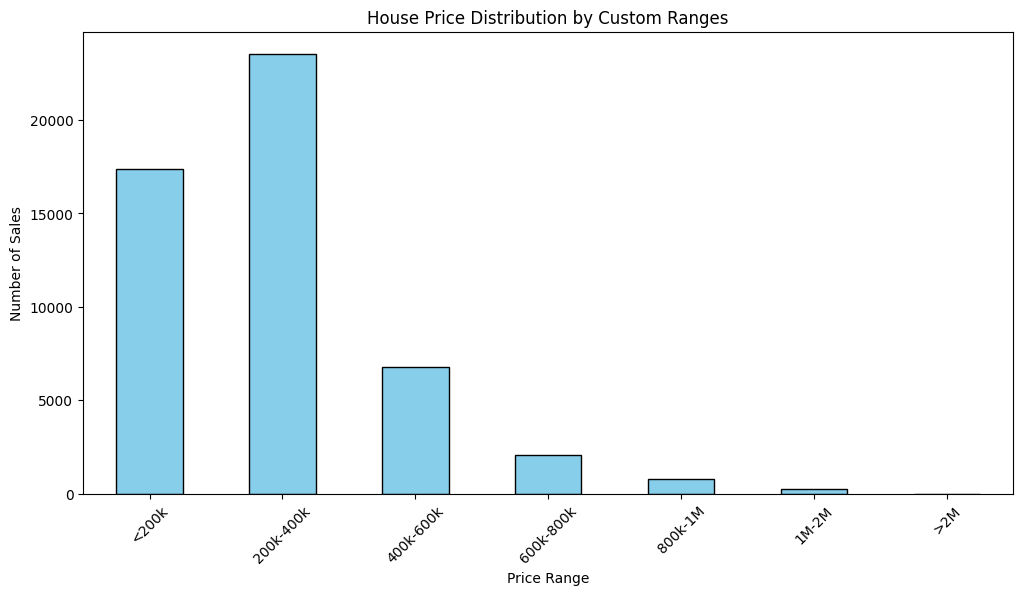

Train shape after outlier removal: (50793, 9)


In [10]:
# detect outliers
outliers = train_df[(train_df['Price(1,000 €)'] < lower_bound) | (train_df['Price(1,000 €)'] > upper_bound)]

print(f"sample size: {len(train_df)}")
print(f"abnormal value: {len(outliers)}")

train_df = train_df[(train_df['Price(1,000 €)'] >= lower_bound) & (train_df['Price(1,000 €)'] <= upper_bound)].copy()

# binning and visualization
train_df['Price_Range'] = pd.cut(train_df['Price(1,000 €)'], bins=bins, labels=labels)
test_df['Price_Range'] = pd.cut(test_df['Price(1,000 €)'], bins=bins, labels=labels)
counts = train_df['Price_Range'].value_counts().reindex(labels) 

plt.figure(figsize=(12, 6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('House Price Distribution by Custom Ranges')
plt.ylabel('Number of Sales')
plt.xlabel('Price Range')
plt.xticks(rotation=45)
plt.show()

print("Train shape after outlier removal:", train_df.shape)

## Date of Sale: Temporal Feature Extraction

The original sale date is converted into structured time features that are more useful for analysis and modelling. In particular, year captures longer-run market movement, while quarter captures within-year seasonal variation.

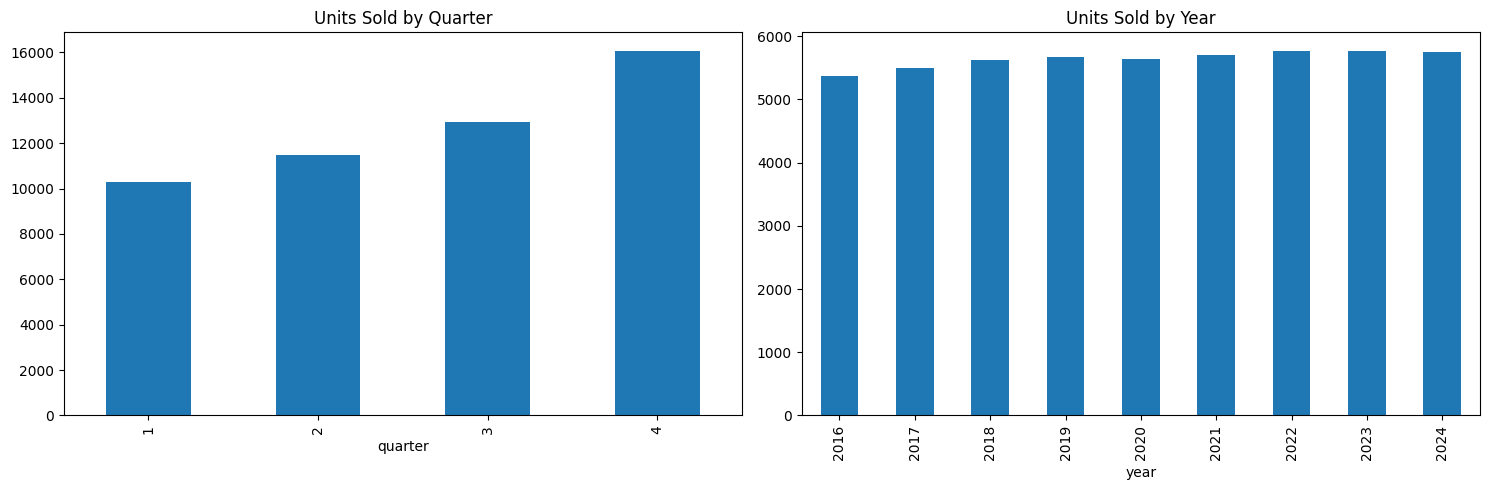

In [11]:
# Year / Quarter from sale date
# -----------------------------
# TRAIN
# -----------------------------
train_df["Date of Sale"] = pd.to_datetime(
    train_df["Date of Sale (dd/mm/yyyy)"],
    format="%d/%m/%Y",
    errors="coerce"
)

train_df["year"] = train_df["Date of Sale"].dt.year
train_df["quarter"] = train_df["Date of Sale"].dt.quarter.astype("category")

train_df = train_df.drop(columns=["Date of Sale (dd/mm/yyyy)", "Date of Sale"])

# -----------------------------
# TEST
# -----------------------------
test_df["Date of Sale"] = pd.to_datetime(
    test_df["Date of Sale (dd/mm/yyyy)"],
    format="%d/%m/%Y",
    errors="coerce"
)

test_df["year"] = test_df["Date of Sale"].dt.year
test_df["quarter"] = test_df["Date of Sale"].dt.quarter.astype("category")

# normalise year using the training-set minimum
train_df["year_norm"] = train_df["year"] - train_df["year"].min()
test_df["year_norm"] = test_df["year"] - train_df["year"].min()

test_df = test_df.drop(columns=["Date of Sale (dd/mm/yyyy)", "Date of Sale"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train_df["quarter"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Units Sold by Quarter")

train_df["year"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Units Sold by Year")

plt.tight_layout()
plt.show()

## Categorical Variables: Standardisation and Binary Encoding

This subsection standardises the retained categorical variables and converts selected yes/no fields and property-status information into binary features suitable for later modelling.

In [12]:
print(train_df["Description of Property"].unique())
print(train_df["VAT Exclusive"].unique())
print(train_df["Not Full Market Price"].unique())

['Second-Hand Dwelling house /Apartment' 'New Dwelling house /Apartment'
 'Teach/Árasán Cónaithe Atháimhe' 'Teach/Árasán Cónaithe Nua']
['No' 'Yes']
['No' 'Yes']


In [13]:
# -----------------------------
# Standardise retained text fields
# -----------------------------
for df in [train_df, test_df]:
    for col in ["County", "Address", "Description of Property", "VAT Exclusive", "Not Full Market Price"]:
        df[col] = df[col].astype("string").str.strip()

# Fill retained categorical/text variables
train_df["County"] = train_df["County"].fillna("Unknown")
test_df["County"] = test_df["County"].fillna("Unknown")

train_df["Address"] = train_df["Address"].fillna("Unknown")
test_df["Address"] = test_df["Address"].fillna("Unknown")

property_mode = train_df["Description of Property"].mode(dropna=True)[0]
vat_mode = train_df["VAT Exclusive"].mode(dropna=True)[0]
nfmp_mode = train_df["Not Full Market Price"].mode(dropna=True)[0]

train_df["Description of Property"] = train_df["Description of Property"].fillna(property_mode)
test_df["Description of Property"] = test_df["Description of Property"].fillna(property_mode)

train_df["VAT Exclusive"] = train_df["VAT Exclusive"].fillna(vat_mode)
test_df["VAT Exclusive"] = test_df["VAT Exclusive"].fillna(vat_mode)

train_df["Not Full Market Price"] = train_df["Not Full Market Price"].fillna(nfmp_mode)
test_df["Not Full Market Price"] = test_df["Not Full Market Price"].fillna(nfmp_mode)

# Standardise Irish / English labels
replacement_map = {
    "Teach/Árasán Cónaithe Atháimhe": "Second-Hand Dwelling house /Apartment",
    "Teach/Árasán Cónaithe Nua": "New Dwelling house /Apartment"
}

train_df["Description of Property"] = train_df["Description of Property"].replace(replacement_map)
test_df["Description of Property"] = test_df["Description of Property"].replace(replacement_map)

# Convert Yes/No columns to binary
yn_map = {"Yes": 1, "No": 0}

train_df["Not Full Market Price"] = train_df["Not Full Market Price"].map(yn_map).astype("int64")
train_df["VAT Exclusive"] = train_df["VAT Exclusive"].map(yn_map).astype("int64")
test_df["Not Full Market Price"] = test_df["Not Full Market Price"].map(yn_map).astype("int64")
test_df["VAT Exclusive"] = test_df["VAT Exclusive"].map(yn_map).astype("int64")

# Convert property description into binary variable
train_df["is_new_property"] = (
    train_df["Description of Property"] == "New Dwelling house /Apartment"
).astype("int64")
test_df["is_new_property"] = (
    test_df["Description of Property"] == "New Dwelling house /Apartment"
).astype("int64")

# Drop original text field after encoding
train_df = train_df.drop(columns=["Description of Property"])
test_df = test_df.drop(columns=["Description of Property"])

print(train_df[["VAT Exclusive", "Not Full Market Price", "is_new_property"]].head())
print("\nRemaining missing values in train after categorical cleaning:")
print(train_df.isna().sum().sort_values(ascending=False))

   VAT Exclusive  Not Full Market Price  is_new_property
0              0                      0                0
1              0                      0                0
2              1                      1                1
3              0                      0                0
4              0                      0                0

Remaining missing values in train after categorical cleaning:
Address                  0
County                   0
Not Full Market Price    0
VAT Exclusive            0
row_id                   0
Price(1,000 €)           0
Price_Range              0
year                     0
quarter                  0
year_norm                0
is_new_property          0
dtype: int64


In [14]:
# Keep only rows with missing values in critical analytic fields removed
train_df = train_df.dropna(subset=["Price(1,000 €)", "year", "quarter", "year_norm"]).copy()
test_df = test_df.dropna(subset=["Price(1,000 €)", "year", "quarter", "year_norm"]).copy()

# Drop helper column created only for exploratory visualisation
train_clean_final = train_df.drop(columns=["Price_Range"], errors="ignore").copy()
test_clean_final = test_df.drop(columns=["Price_Range"], errors="ignore").copy()

print("Remaining missing values in train_clean_final:")
print(train_clean_final.isna().sum().sort_values(ascending=False))

print("\nRemaining missing values in test_clean_final:")
print(test_clean_final.isna().sum().sort_values(ascending=False))

# Save clean-final datasets for Parts 1 and 2
train_clean_final.to_csv("ppr-group-24209891-train-clean-final.csv", index=False)
test_clean_final.to_csv("ppr-group-24209891-test-clean-final.csv", index=False)

print("\nSaved clean-final datasets.")
print("Final train shape:", train_clean_final.shape)
print("Final test shape:", test_clean_final.shape)

Remaining missing values in train_clean_final:
Address                  0
County                   0
Not Full Market Price    0
VAT Exclusive            0
row_id                   0
Price(1,000 €)           0
year                     0
quarter                  0
year_norm                0
is_new_property          0
dtype: int64

Remaining missing values in test_clean_final:
Address                  0
County                   0
Not Full Market Price    0
VAT Exclusive            0
row_id                   0
Price(1,000 €)           0
year                     0
quarter                  0
year_norm                0
is_new_property          0
dtype: int64

Saved clean-final datasets.
Final train shape: (50793, 10)
Final test shape: (9999, 10)


In [15]:
final_schema = pd.DataFrame({
    "column": train_clean_final.columns,
    "dtype": train_clean_final.dtypes.astype(str).values,
    "missing_count": train_clean_final.isna().sum().values,
    "n_unique": [train_clean_final[col].nunique(dropna=True) for col in train_clean_final.columns]
})

print("Final schema of train_clean_final:")
display(final_schema)

Final schema of train_clean_final:


,column,dtype,missing_count,n_unique
0,Address,string,0,50228
1,County,string,0,26
2,Not Full Market Price,int64,0,2
3,VAT Exclusive,int64,0,2
4,row_id,int64,0,50793
5,"Price(1,000 €)",float64,0,4773
6,year,int32,0,9
7,quarter,category,0,4
8,year_norm,int32,0,9
9,is_new_property,int64,0,2


### Summary of Part 1 and Part 2

The raw training dataset required several targeted cleaning steps before it could be used reliably. The main issues were duplicated rows, non-standard price formatting, high-missingness fields, and categorical text variables requiring standardisation. 

`Eircode` and `Property Size Description` were removed from the clean-final dataset because of their high missingness and limited direct value in the current clean-final workflow. The retained variables were converted into appropriate numeric or categorical forms, and the cleaned training dataset was exported for later stages of the project. Spatial information is reintroduced later through external geocoding and a derived distance-based feature.

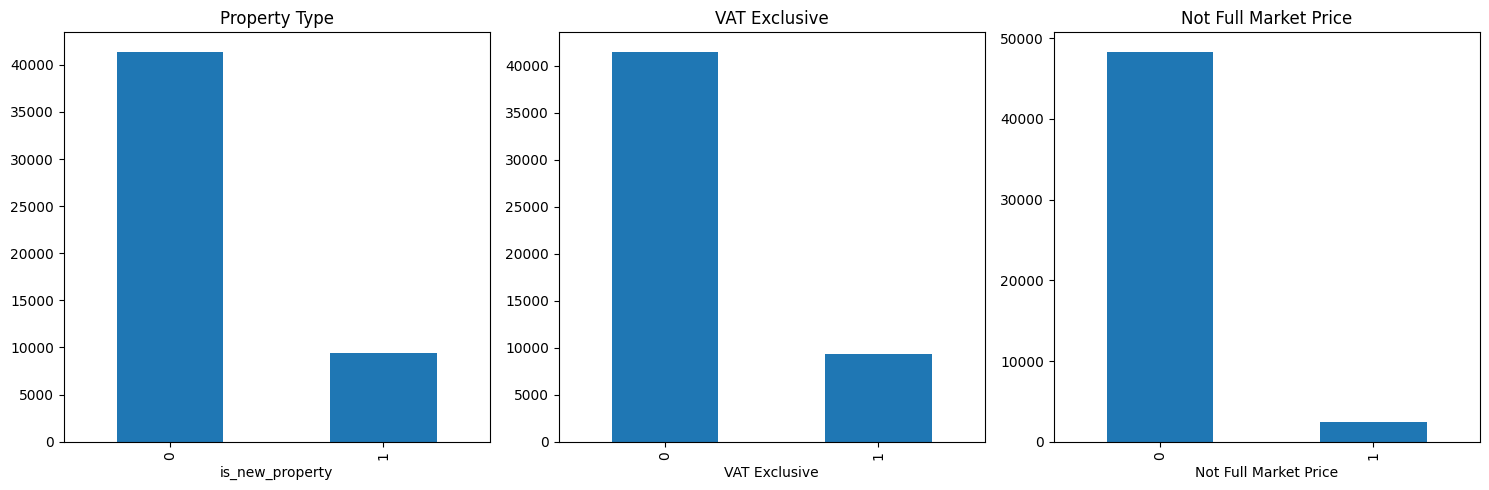

In [16]:
# distribution according to not full market price, vat exclusive and property type
fig, axes = plt.subplots(1, 3, figsize=(15,5))

train_df["is_new_property"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Property Type")

train_df["VAT Exclusive"].value_counts().head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("VAT Exclusive")

train_df["Not Full Market Price"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Not Full Market Price")

plt.tight_layout()
plt.show()

## Location Variable - County

Location is expected to be one of the strongest drivers of house prices. We therefore examine the county-level distribution of transactions and compare average prices across counties before moving to explicit location-based feature engineering.

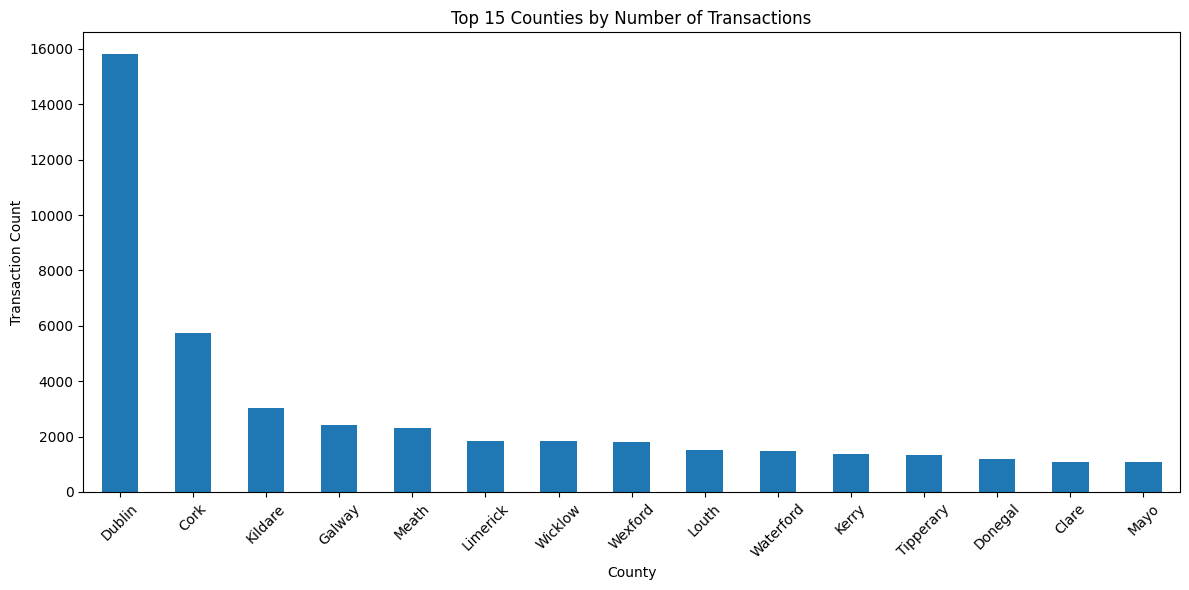

In [17]:
county_counts = train_df["County"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
county_counts.head(15).plot(kind="bar")
plt.title("Top 15 Counties by Number of Transactions")
plt.ylabel("Transaction Count")
plt.xlabel("County")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Part 3. Exploring Relationships Between Feature Pairs

This section examines pairwise relationships between price and a subset of explanatory variables, including time, property status, transaction indicators, and location. The goal is to identify patterns that justify feature retention and motivate the next stage of feature engineering.

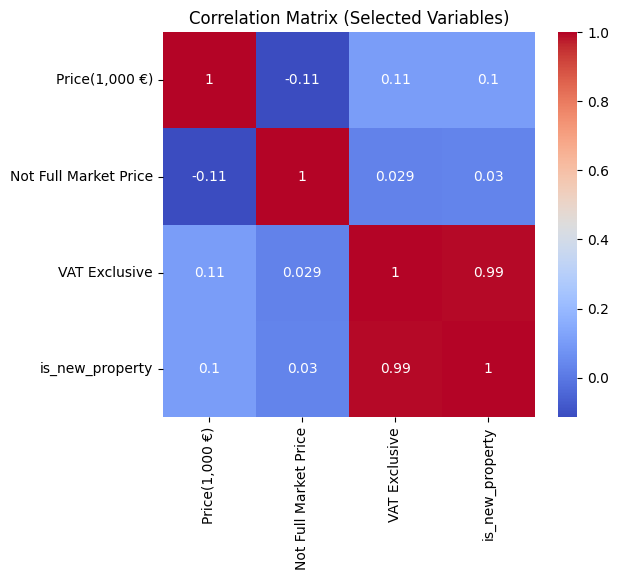

In [18]:
# Correlation Matrix
import seaborn as sns

selected_vars = ["Price(1,000 €)", "Not Full Market Price", "VAT Exclusive", "is_new_property"]

corr_matrix = train_df[selected_vars].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix (Selected Variables)")
plt.show()

/var/folders/1s/_x0ql_p94d302thrdx6rk96h0000gn/T/ipykernel_25392/1874401976.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby("quarter")["Price(1,000 €)"].mean().plot(kind="line", ax=axes[0,0], title="Quarter")


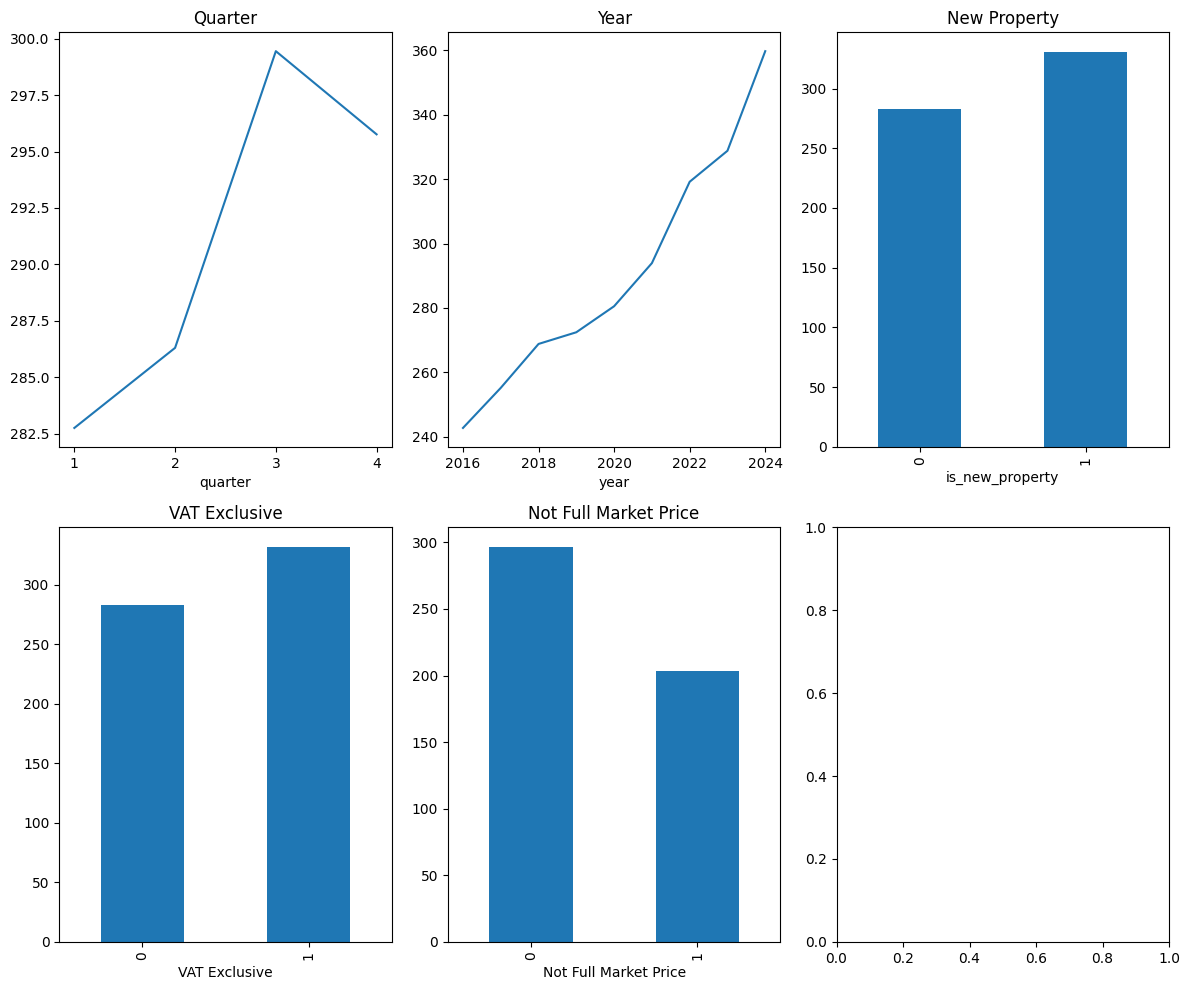

In [19]:
# average price group by quarter and binary binary variables
fig, axes = plt.subplots(2,3, figsize=(12,10))

train_df.groupby("quarter")["Price(1,000 €)"].mean().plot(kind="line", ax=axes[0,0], title="Quarter")

train_df.groupby("year")["Price(1,000 €)"].mean().plot(kind="line", ax=axes[0,1], title="Year")

train_df.groupby("is_new_property")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[0,2], title="New Property")

train_df.groupby("VAT Exclusive")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[1,0], title="VAT Exclusive")

train_df.groupby("Not Full Market Price")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[1,1], title="Not Full Market Price")

plt.tight_layout()
plt.show()

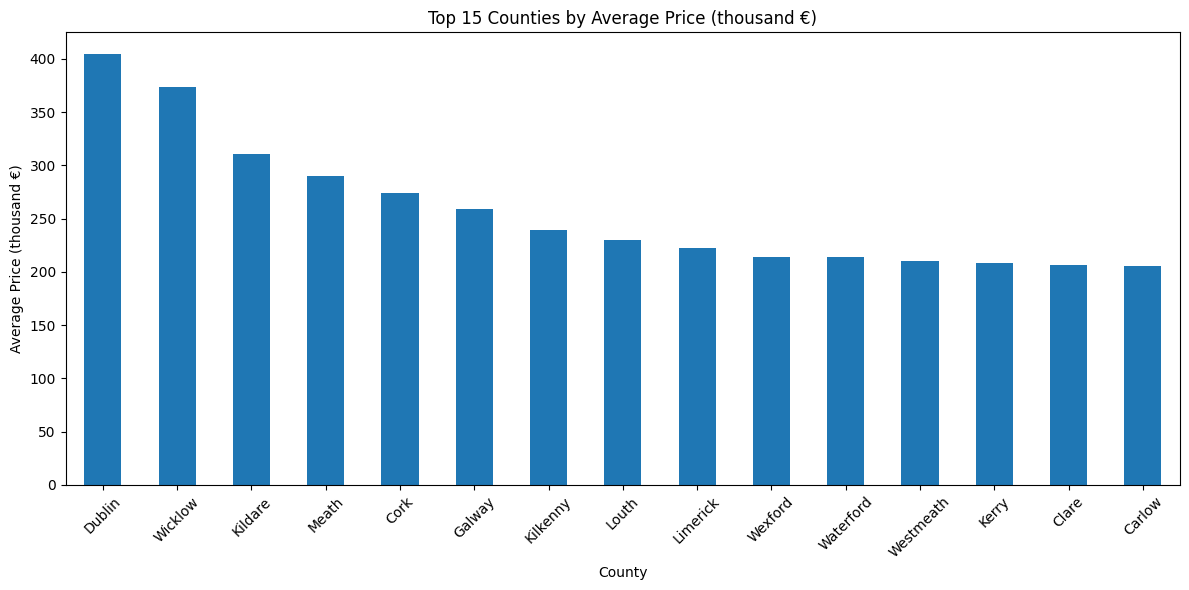

In [20]:
county_avg_price = train_df.groupby("County")["Price(1,000 €)"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
county_avg_price.head(15).plot(kind="bar")
plt.title("Top 15 Counties by Average Price (thousand €)")
plt.ylabel("Average Price (thousand €)")
plt.xlabel("County")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Summary of Part 3

The exploratory analysis indicates that price is associated with a combination of temporal, locational, and transaction-related variables. County-level differences are substantial, and time-based variation is also visible across years and quarters. Binary indicators such as `is_new_property`, `VAT Exclusive`, and `Not Full Market Price` also show meaningful differences in average price, supporting their retention for predictive modelling.

# Part 4. Creating New Features

This section extends the clean-final dataset with location-based information derived from externally geocoded latitude and longitude data. Because the original `Eircode` field is highly incomplete, spatial information is recovered through geocoded coordinates and then summarised using a compact derived feature: distance to a county-level economic centre.

The main engineered features used in the modelling stage are:
1. `year_norm`, capturing long-run temporal movement;
2. `quarter`, capturing seasonality;
3. `distance_to_local_economic_center_km`, capturing a compact spatial proxy.

In addition, `is_new_property` is retained as a derived binary feature based on the cleaned property description field.

In [21]:
"""
# -----------------------------
# Load
# Due to access limit (2500 /key/day), this part of code is executed by three members in 7 days seperately
# -----------------------------

df = pd.read_csv("ppr-group-24209891-train.csv")

df = df.reset_index(drop=True)

import requests
import time
from tqdm import tqdm

API_KEY = "YOUR_API_KEY" # Your API Key go to https://opencagedata.com/ and get key; only 2500 rows per day

CSV_OUT = "your_file_name.csv" 

ADDRESS_COL = "Address"
COUNTY_COL = "County"

# Create empty columns
df["lat"] = None
df["lng"] = None

def geocode(address):
    url = "https://api.opencagedata.com/geocode/v1/json"
    params = {
        "q": address,
        "key": API_KEY,
        "countrycode": "ie",
        "limit": 1
    }
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        return None, None
    
    data = response.json()
    if data["results"]:
        lat = data["results"][0]["geometry"]["lat"]
        lng = data["results"][0]["geometry"]["lng"]
        return lat, lng
    return None, None

for i in tqdm(range(len(df))):
    address = str(df.loc[i, ADDRESS_COL]) + ", " + str(df.loc[i, COUNTY_COL]) + ", Ireland"
    
    lat, lng = geocode(address)
    
    df.loc[i, "lat"] = lat
    df.loc[i, "lng"] = lng
    
    time.sleep(1)  # IMPORTANT: avoid rate limit

df.to_csv(CSV_OUT, index=False)
"""
"""
# -----------------------------
# Load: after all longitute and latitude data available, we combine all of them into one table
# -----------------------------
import glob

files = glob.glob("path_to_data_file")

dfs = [pd.read_csv(f) for f in files]

df = pd.concat(dfs, ignore_index=True)

df.to_csv("train.csv", index=False)
"""

'\n# -----------------------------\n# Load: after all longitute and latitude data available, we combine all of them into one table\n# -----------------------------\nimport glob\n\nfiles = glob.glob("path_to_data_file")\n\ndfs = [pd.read_csv(f) for f in files]\n\ndf = pd.concat(dfs, ignore_index=True)\n\ndf.to_csv("train.csv", index=False)\n'

In [22]:
geo_train = pd.read_csv("ppr-group-24209891-train-geocoded.csv")
geo_test = pd.read_csv("ppr-group-24209891-test-geocoded.csv")

geo_train.columns = geo_train.columns.str.strip()
geo_test.columns = geo_test.columns.str.strip()

geo_train["row_id"] = np.arange(len(geo_train))
geo_test["row_id"] = np.arange(len(geo_test))

train_df = train_df.merge(
    geo_train[["row_id", "lat", "lng"]],
    on="row_id",
    how="left"
)

test_df = test_df.merge(
    geo_test[["row_id", "lat", "lng"]],
    on="row_id",
    how="left"
)

print("Missing lat in train:", train_df["lat"].isna().sum())
print("Missing lng in train:", train_df["lng"].isna().sum())
print("Missing lat in test:", test_df["lat"].isna().sum())
print("Missing lng in test:", test_df["lng"].isna().sum())

Missing lat in train: 1066
Missing lng in train: 1066
Missing lat in test: 5
Missing lng in test: 5


In [23]:
# Calculate the distance

from math import radians, sin, cos, sqrt, atan2

# =========================
# Config
# =========================

COUNTY_COL = "County"   # change if your column name differs
LAT_COL    = "lat"      # must exist in your data (from geocoding)
LNG_COL    = "lng"      # must exist in your data (from geocoding)

OUT_COL = "distance_to_local_economic_center_km"

# =========================
# County -> local economic center (approx)
# =========================
# NOTE:
# - These are practical “center city/town” coordinates for each county.
# - If your county names differ (e.g., "Co. Dublin", "Dublin City"), the normalizer below helps.
county_center = {
    "carlo": (52.8365, -6.9341),          # Carlow
    "cavan": (53.9900, -7.3600),          # Cavan
    "clare": (52.6638, -8.6267),          # Limerick (strongest nearby hub); alternative: Ennis
    "cork": (51.8985, -8.4756),           # Cork
    "donegal": (54.6540, -8.1100),        # Letterkenny-ish region
    "dublin": (53.3498, -6.2603),         # Dublin
    "galway": (53.2707, -9.0568),         # Galway
    "kerry": (52.1545, -9.5669),          # Tralee/Killarney area
    "kildare": (53.1593, -6.9099),        # Naas
    "kilkenny": (52.6541, -7.2448),       # Kilkenny
    "laois": (53.0340, -7.2990),          # Portlaoise
    "leitrim": (54.1250, -8.0000),        # Carrick-on-Shannon area
    "limerick": (52.6638, -8.6267),       # Limerick
    "longford": (53.7275, -7.7930),       # Longford
    "louth": (53.9979, -6.4023),          # Dundalk/Drogheda corridor
    "mayo": (53.8550, -9.2980),           # Castlebar/Westport area
    "meath": (53.6055, -6.6564),          # Navan
    "monaghan": (54.2492, -6.9683),       # Monaghan
    "offaly": (53.2734, -7.7783),         # Tullamore
    "roscommon": (53.7598, -8.2682),      # Roscommon
    "sligo": (54.2766, -8.4761),          # Sligo
    "tipperary": (52.4738, -8.1557),      # Thurles/Cashel area
    "waterford": (52.2593, -7.1101),      # Waterford
    "westmeath": (53.5266, -7.3386),      # Mullingar/Athlone corridor
    "wexford": (52.3369, -6.4633),        # Wexford
    "wicklow": (52.9862, -6.3675),        # Wicklow
}

# Some datasets use "Laois" as "Queen's County" historically (rare); add aliases if needed.
county_alias = {
    "co dublin": "dublin",
    "county dublin": "dublin",
    "dublin city": "dublin",
    "co cork": "cork",
    "county cork": "cork",
    "co galway": "galway",
    "county galway": "galway",
    "co limerick": "limerick",
    "county limerick": "limerick",
    "co waterford": "waterford",
    "county waterford": "waterford",
}

def normalize_county(x) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = s.replace(".", "").replace(",", "")
    s = " ".join(s.split())
    # map aliases
    if s in county_alias:
        return county_alias[s]
    # also handle "co <name>"
    if s.startswith("co "):
        s2 = s[3:].strip()
        return county_alias.get(s, s2)
    if s.startswith("county "):
        return s[7:].strip()
    return s

# =========================
# Haversine distance (km)
# =========================
def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

def compute_distance(row) -> float | None:
    lat = row.get(LAT_COL, None)
    lng = row.get(LNG_COL, None)
    if pd.isna(lat) or pd.isna(lng):
        return None

    county_raw = row.get(COUNTY_COL, "")
    county = normalize_county(county_raw)
    if not county:
        return None

    center = county_center.get(county)
    if center is None:
        return None

    c_lat, c_lng = center
    return haversine_km(float(lat), float(lng), c_lat, c_lng)

# =========================
# Run
# =========================

# Create distance feature
train_df[OUT_COL] = train_df.apply(compute_distance, axis=1)
test_df[OUT_COL] = test_df.apply(compute_distance, axis=1)

train_df.head(5)

,Address,County,Not Full Market Price,VAT Exclusive,row_id,"Price(1,000 €)",Price_Range,year,quarter,year_norm,is_new_property,lat,lng,distance_to_local_economic_center_km
0,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,0,0,0,125.0,<200k,2016,4,0,0,53.327500,-8.21944,56.003110
1,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,0,0,1,100.0,<200k,2016,2,0,0,54.950000,-7.73333,40.818330
2,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,1,1,2,175.0,<200k,2016,4,0,1,53.333060,-6.24889,2.009631
3,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,0,0,3,65.0,<200k,2016,2,0,0,53.990830,-7.36056,0.099288
4,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,0,0,4,190.0,<200k,2016,3,0,0,53.296101,-6.49200,16.506682


In [24]:
print("Missing values after creating the distance feature:")
print(train_df.isna().sum().sort_values(ascending=False))

Missing values after creating the distance feature:
distance_to_local_economic_center_km    1619
lat                                     1066
lng                                     1066
Address                                    0
County                                     0
Not Full Market Price                      0
VAT Exclusive                              0
row_id                                     0
Price(1,000 €)                             0
Price_Range                                0
year                                       0
quarter                                    0
year_norm                                  0
is_new_property                            0
dtype: int64


In [25]:
# Fill missing distance values using county median, then global median
county_distance_median = train_df.groupby("County")[OUT_COL].median()
global_distance_median = train_df[OUT_COL].median()

def fill_distance(df):
    df = df.copy()
    df[OUT_COL] = df[OUT_COL].fillna(df["County"].map(county_distance_median))
    df[OUT_COL] = df[OUT_COL].fillna(global_distance_median)
    return df

train_df = fill_distance(train_df)
test_df = fill_distance(test_df)

print(train_df["distance_to_local_economic_center_km"].isna().sum())
print(test_df["distance_to_local_economic_center_km"].isna().sum())

# Keep only rows with valid target and key time fields
train_df = train_df.dropna(subset=["Price(1,000 €)", "year", "quarter", "year_norm"]).copy()
test_df = test_df.dropna(subset=["Price(1,000 €)", "year", "quarter", "year_norm"]).copy()

# Formatting location and time variables
train_df["County"] = train_df["County"].astype(str).str.strip()
train_df["quarter"] = train_df["quarter"].astype(str).str.strip()
test_df["County"] = test_df["County"].astype(str).str.strip()
test_df["quarter"] = test_df["quarter"].astype(str).str.strip()

# Rename variables for modelling
train_df = train_df.rename(columns={
    "Price(1,000 €)": "price",
    "distance_to_local_economic_center_km": "distance",
    "Not Full Market Price": "not_full_price",
    "VAT Exclusive": "vatx",
})
test_df = test_df.rename(columns={
    "Price(1,000 €)": "price",
    "distance_to_local_economic_center_km": "distance",
    "Not Full Market Price": "not_full_price",
    "VAT Exclusive": "vatx",
})

# Drop intermediate variables
train_df = train_df.drop(columns=["lat", "lng"], errors="ignore")
test_df = test_df.drop(columns=["lat", "lng"], errors="ignore")

# Log-transform target
train_df["LnP"] = np.log(train_df["price"])
test_df["LnP"] = np.log(test_df["price"])

# Drop helper target-derived column before exporting engineered datasets
train_df = train_df.drop(columns=["Price_Range"], errors="ignore")
test_df = test_df.drop(columns=["Price_Range"], errors="ignore")

# Save engineered datasets
train_df.to_csv("ppr-group-24209891-train-engineered.csv", index=False)
test_df.to_csv("ppr-group-24209891-test-engineered.csv", index=False)

print("Remaining missing values in train:")
print(train_df.isna().sum().sort_values(ascending=False))
print("\nRemaining missing values in test:")
print(test_df.isna().sum().sort_values(ascending=False))
print("\nSaved engineered datasets.")

0
0
Remaining missing values in train:
Address            0
County             0
not_full_price     0
vatx               0
row_id             0
price              0
year               0
quarter            0
year_norm          0
is_new_property    0
distance           0
LnP                0
dtype: int64

Remaining missing values in test:
Address            0
County             0
not_full_price     0
vatx               0
row_id             0
price              0
year               0
quarter            0
year_norm          0
is_new_property    0
distance           0
LnP                0
dtype: int64

Saved engineered datasets.


In [26]:
train_df[["price", "distance", "year_norm", "LnP"]].describe()

,price,distance,year_norm,LnP
count,50793.000000,50793.000000,50793.000000,50793.000000
mean,291.928200,120.859242,4.052606,5.508908
std,175.479152,79.439037,2.573129,0.590284
min,55.500000,0.052998,0.000000,4.016383
25%,170.000000,48.555053,2.000000,5.135798
50%,257.000000,118.268321,4.000000,5.549076
75%,365.000000,185.453025,6.000000,5.899897
max,1190.000000,392.984927,8.000000,7.081709


### Summary of Part 4

The engineered features extend the cleaned dataset without using the target variable directly. `year_norm` captures temporal trend, `quarter` captures seasonality, and `distance` provides a compact location-based proxy derived from geocoded coordinates. Together with `is_new_property`, these features provide a more informative representation for modelling than the raw fields alone.

# Part 5. Training and Evaluating Prediction Models

This section compares an interpretable linear baseline model with a Random Forest model that can capture more complex nonlinear structure. Performance is evaluated using multiple metrics on the training data, the hold-out test data, and cross-validation in order to assess both fit and generalisation.

## Model 1. Linear Regression (OLS with County and Quarter Fixed Effects)

In [27]:
import statsmodels.formula.api as smf

ols_vars = [
    "LnP", "distance", "not_full_price", "vatx",
    "is_new_property", "year_norm", "County", "quarter"
]

ols_train_df = train_df[ols_vars].dropna().copy()

model = smf.ols(
    formula="LnP ~ distance + not_full_price + vatx + is_new_property + year_norm + C(County) + C(quarter)",
    data=ols_train_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": ols_train_df["County"]}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    LnP   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                 2.947e+04
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.05e-47
Time:                        14:01:49   Log-Likelihood:                -32700.
No. Observations:               50793   AIC:                         6.547e+04
Df Residuals:                   50759   BIC:                         6.577e+04
Df Model:                          33                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  4

/opt/anaconda3/envs/comp47350py312/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 33, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [28]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

ols_test_df = test_df[ols_vars].dropna().copy()

ols_train_pred = model.predict(ols_train_df)
ols_test_pred = model.predict(ols_test_df)

ols_metrics = pd.DataFrame([
    {"dataset": "train", **regression_metrics(ols_train_df["LnP"], ols_train_pred)},
    {"dataset": "test", **regression_metrics(ols_test_df["LnP"], ols_test_pred)},
])

display(ols_metrics)

lin_features = ["distance", "not_full_price", "vatx", "is_new_property", "County", "quarter", "year_norm"]
X_lin = pd.get_dummies(ols_train_df[lin_features], drop_first=True)
y_lin = ols_train_df["LnP"]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lin_cv = cross_validate(
    LinearRegression(),
    X_lin,
    y_lin,
    cv=cv,
    scoring=("r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"),
    return_train_score=True
)

ols_cv_summary = pd.DataFrame({
    "train_R2_mean": [lin_cv["train_r2"].mean()],
    "cv_R2_mean": [lin_cv["test_r2"].mean()],
    "train_RMSE_mean": [-lin_cv["train_neg_root_mean_squared_error"].mean()],
    "cv_RMSE_mean": [-lin_cv["test_neg_root_mean_squared_error"].mean()],
    "train_MAE_mean": [-lin_cv["train_neg_mean_absolute_error"].mean()],
    "cv_MAE_mean": [-lin_cv["test_neg_mean_absolute_error"].mean()],
})

display(ols_cv_summary)

,dataset,R2,RMSE,MAE
0,train,0.391016,0.460638,0.356879
1,test,0.290350,0.567646,0.387776


,train_R2_mean,cv_R2_mean,train_RMSE_mean,cv_RMSE_mean,train_MAE_mean,cv_MAE_mean
0,0.391126,0.389797,0.460593,0.461041,0.356849,0.357189


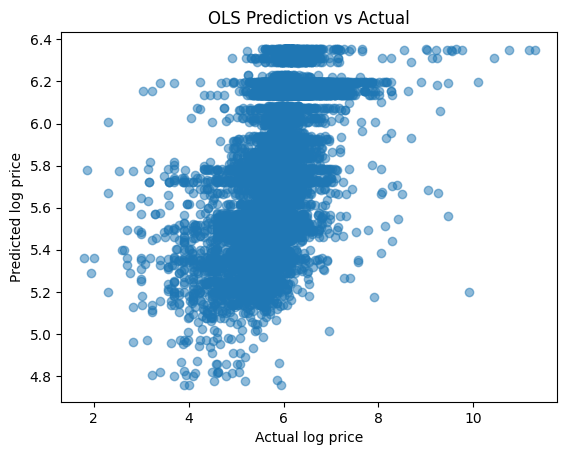

In [29]:
plt.scatter(ols_test_df["LnP"], ols_test_pred, alpha=0.5)
plt.xlabel("Actual log price")
plt.ylabel("Predicted log price")
plt.title("OLS Prediction vs Actual")
plt.show()

## Model 2. Random Forest Regressor

In [30]:
from sklearn.ensemble import RandomForestRegressor
features = [
    "distance",
    "not_full_price",
    "vatx",
    "is_new_property",
    "County",
    "quarter",
    "year_norm"
]

X_train = pd.get_dummies(train_df[features], drop_first=True)
y_train = train_df["LnP"]

X_test = pd.get_dummies(test_df[features], drop_first=True)
y_test = test_df["LnP"]

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [31]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

rf_metrics = pd.DataFrame([
    {"dataset": "train", **regression_metrics(y_train, rf_train_pred)},
    {
        "dataset": "oob",
        "R2": rf.oob_score_,
        "RMSE": root_mean_squared_error(y_train, rf.oob_prediction_),
        "MAE": mean_absolute_error(y_train, rf.oob_prediction_)
    },
    {"dataset": "test", **regression_metrics(y_test, rf_test_pred)},
])

display(rf_metrics)

rf_cv = cross_validate(
    RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    X_train,
    y_train,
    cv=cv,
    scoring=("r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"),
    return_train_score=True,
    n_jobs=-1
)

rf_cv_summary = pd.DataFrame({
    "train_R2_mean": [rf_cv["train_r2"].mean()],
    "cv_R2_mean": [rf_cv["test_r2"].mean()],
    "train_RMSE_mean": [-rf_cv["train_neg_root_mean_squared_error"].mean()],
    "cv_RMSE_mean": [-rf_cv["test_neg_root_mean_squared_error"].mean()],
    "train_MAE_mean": [-rf_cv["train_neg_mean_absolute_error"].mean()],
    "cv_MAE_mean": [-rf_cv["test_neg_mean_absolute_error"].mean()],
})

display(rf_cv_summary)

,dataset,R2,RMSE,MAE
0,train,0.779406,0.277239,0.198659
1,oob,0.263219,0.506671,0.392147
2,test,0.187889,0.607244,0.422451


,train_R2_mean,cv_R2_mean,train_RMSE_mean,cv_RMSE_mean,train_MAE_mean,cv_MAE_mean
0,0.786636,0.259844,0.272652,0.507765,0.195387,0.393307


distance           0.390999
County_Dublin      0.219637
year_norm          0.112728
vatx               0.031987
not_full_price     0.026793
quarter_4          0.024476
County_Wicklow     0.024143
quarter_3          0.023524
quarter_2          0.023197
County_Kildare     0.019849
County_Cork        0.018457
County_Meath       0.015904
County_Galway      0.009990
County_Donegal     0.004399
County_Limerick    0.003983
dtype: float64

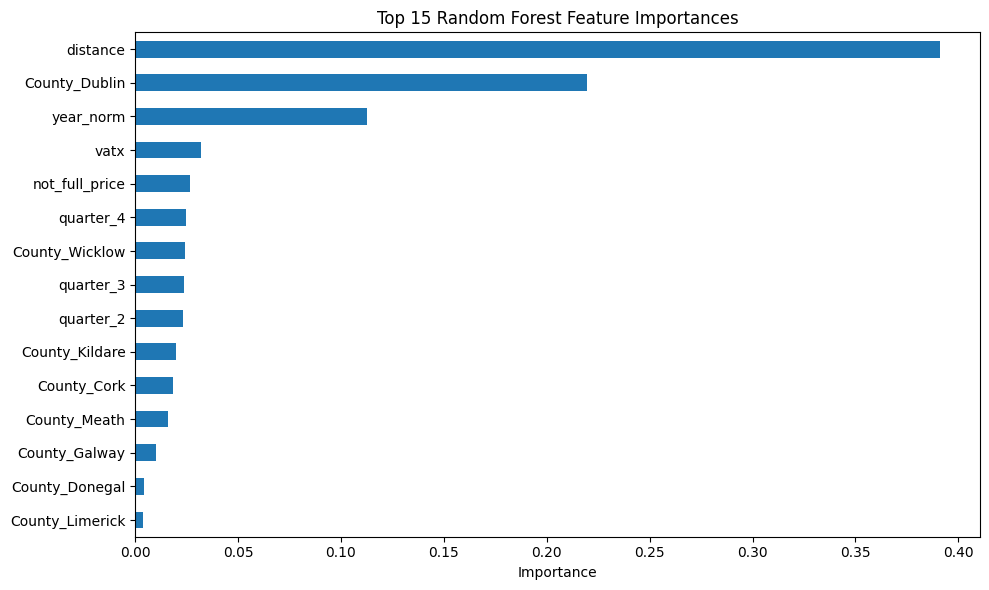

In [32]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

display(importance.head(15))

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [33]:
rf_tuned = RandomForestRegressor(
    n_estimators=600,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
rf_tuned_test_pred = rf_tuned.predict(X_test)

tuned_results = pd.DataFrame([
    {"model": "RF_baseline_test", **regression_metrics(y_test, rf_test_pred)},
    {"model": "RF_tuned_test", **regression_metrics(y_test, rf_tuned_test_pred)},
])

display(tuned_results)

,model,R2,RMSE,MAE
0,RF_baseline_test,0.187889,0.607244,0.422451
1,RF_tuned_test,0.269897,0.575768,0.392934


### Summary of Part 5

The OLS model provides an interpretable baseline and allows the effects of time, location, transaction status, and property type to be examined directly. The Random Forest model relaxes linearity assumptions and is able to capture more complex interactions. Final model choice should be based on generalisation performance rather than training fit alone. In particular, a large gap between training and cross-validation or test performance would indicate overfitting, while uniformly weak results would suggest underfitting.

In the final comparison, the OLS model delivered the strongest hold-out performance in this notebook, outperforming both the baseline and tuned Random Forest models on the test set. This suggests that the main predictive structure in the current feature set is largely linear and additive, and that the Random Forest models are more prone to overfitting under the present specification.